# Site-Level EDA

Site-level profiling of electricity consumption, data quality, temporal patterns, and metadata mix.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

DATA_DIR  = Path('../../../data/raw/data')
ELEC_PATH = DATA_DIR / 'meters/cleaned/electricity_cleaned.csv'
META_PATH = DATA_DIR / 'metadata/metadata.csv'
from collections import defaultdict
from matplotlib.patches import Patch


In [2]:
elec = pd.read_csv(ELEC_PATH, parse_dates=['timestamp'])
elec.sort_values('timestamp', inplace=True)
elec.reset_index(drop=True, inplace=True)

building_cols = [c for c in elec.columns if c != 'timestamp']
elec_idx = elec.set_index('timestamp')

meta = pd.read_csv(META_PATH)
elec_bld_set = set(building_cols)
meta_bld_set = set(meta['building_id'].dropna())
matched = elec_bld_set & meta_bld_set

print(f'Electricity shape       : {elec.shape}')
print(f'Building columns        : {len(building_cols):,}')
print(f'Metadata shape          : {meta.shape}')
print(f'Matched buildings       : {len(matched):,}')


Electricity shape       : (17544, 1579)
Building columns        : 1,578
Metadata shape          : (1636, 32)
Matched buildings       : 1,578


## 1. Prepare Electricity + Metadata Relationship

In [3]:
# Only buildings present in both datasets
meta_elec = meta[meta['building_id'].isin(building_cols)][['building_id', 'site_id']].copy()
bld_to_site = meta_elec.set_index('building_id')['site_id'].to_dict()

# site -> list of building columns
from collections import defaultdict
site_to_blds = defaultdict(list)
for bld, site in bld_to_site.items():
    site_to_blds[site].append(bld)
site_to_blds = dict(site_to_blds)

sites = sorted(site_to_blds.keys())
print(f'Sites with electricity data: {len(sites)}')
print(f'Sites: {sites}')

Sites with electricity data: 19
Sites: ['Bear', 'Bobcat', 'Bull', 'Cockatoo', 'Crow', 'Eagle', 'Fox', 'Gator', 'Hog', 'Lamb', 'Moose', 'Mouse', 'Panther', 'Peacock', 'Rat', 'Robin', 'Shrew', 'Swan', 'Wolf']


## 2. Site Size Profile

In [4]:
total_blds = sum(len(v) for v in site_to_blds.values())
size_df = pd.DataFrame([
    {'site_id': s, 'n_buildings': len(site_to_blds[s]),
     'pct_total': len(site_to_blds[s]) / total_blds * 100}
    for s in sites
]).sort_values('n_buildings', ascending=False).reset_index(drop=True)

display(size_df.style.format({'pct_total': '{:.1f}%'}))

,site_id,n_buildings,pct_total
0,Rat,305,19.3%
1,Hog,152,9.6%
2,Lamb,146,9.3%
3,Fox,137,8.7%
4,Bull,123,7.8%
5,Cockatoo,117,7.4%
6,Eagle,106,6.7%
7,Panther,105,6.7%
8,Bear,92,5.8%
9,Gator,74,4.7%


## 3. Site Consumption Profile

In [5]:
def site_consumption_stats(site):
    cols = site_to_blds[site]
    vals = elec[cols].values.ravel()
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return {}
    return {
        'site_id'  : site,
        'total'    : vals.sum(),
        'mean'     : vals.mean(),
        'median'   : np.median(vals),
        'std'      : vals.std(),
        'min'      : vals.min(),
        'max'      : vals.max(),
        'p95'      : np.percentile(vals, 95),
        'p99'      : np.percentile(vals, 99),
    }

cons_df = pd.DataFrame([site_consumption_stats(s) for s in sites])
cons_df.sort_values('total', ascending=False, inplace=True)
cons_df.reset_index(drop=True, inplace=True)

display(cons_df.style.format({c: '{:,.2f}' for c in cons_df.columns if c != 'site_id'}))

,site_id,total,mean,median,std,min,max,p95,p99
0,Hog,"608,160,782.68",243.00,107.00,441.77,0.01,"44,336.46",932.58,"2,350.73"
1,Rat,"574,271,756.54",117.03,46.02,241.87,0.01,"3,095.44",471.73,"1,331.04"
2,Bull,"386,911,222.31",185.88,95.00,326.60,0.24,"221,228.00",634.00,"1,074.00"
3,Fox,"361,063,711.67",152.83,86.37,259.59,0.01,"3,193.57",495.31,"1,014.61"
4,Eagle,"339,017,593.60",196.25,105.12,236.40,0.27,"1,989.07",642.76,"1,290.75"
5,Bear,"277,828,976.22",179.60,70.50,284.93,0.01,"2,343.47",775.45,"1,455.52"
6,Cockatoo,"247,124,714.00",135.39,78.38,177.84,0.03,"1,374.17",469.23,896.38
7,Panther,"158,325,765.77",107.18,64.00,123.27,0.02,"1,324.97",402.80,586.95
8,Robin,"143,008,433.61",158.56,85.00,181.22,0.01,"1,544.50",521.20,839.50
9,Moose,"126,448,438.61",630.00,450.91,569.95,0.00,"4,861.70","1,561.36","1,998.74"


## 4. Site Data Quality Profile

In [6]:
def site_quality_stats(site):
    cols = site_to_blds[site]
    sub  = elec[cols]
    total    = sub.size
    missing  = sub.isna().sum().sum()
    zero     = (sub == 0).sum().sum()
    negative = (sub < 0).sum().sum()
    valid    = total - missing
    return {
        'site_id'       : site,
        'total_readings': total,
        'missing'       : missing,
        'missing_rate'  : missing / total if total else np.nan,
        'zeros'         : zero,
        'zero_rate'     : zero / valid if valid else np.nan,
        'negatives'     : negative,
        'negative_rate' : negative / valid if valid else np.nan,
    }

qual_df = pd.DataFrame([site_quality_stats(s) for s in sites])
qual_df.sort_values('missing_rate', ascending=False, inplace=True)
qual_df.reset_index(drop=True, inplace=True)

fmt = {c: '{:.2%}' for c in ['missing_rate', 'zero_rate', 'negative_rate']}
fmt.update({c: '{:,}' for c in ['total_readings', 'missing', 'zeros', 'negatives']})
display(qual_df.style.format(fmt))

,site_id,total_readings,missing,missing_rate,zeros,zero_rate,negatives,negative_rate
0,Swan,"333,336","174,155",52.25%,0,0.00%,0,0.00%
1,Shrew,"157,896","72,040",45.62%,0,0.00%,0,0.00%
2,Bobcat,"614,040","174,622",28.44%,0,0.00%,0,0.00%
3,Mouse,"122,808","30,241",24.62%,0,0.00%,0,0.00%
4,Panther,"1,842,120","364,968",19.81%,0,0.00%,0,0.00%
5,Gator,"1,298,256","175,133",13.49%,0,0.00%,0,0.00%
6,Peacock,"789,480","98,227",12.44%,0,0.00%,0,0.00%
7,Moose,"228,072","27,360",12.00%,0,0.00%,0,0.00%
8,Cockatoo,"2,052,648","227,314",11.07%,0,0.00%,0,0.00%
9,Rat,"5,350,920","443,728",8.29%,0,0.00%,0,0.00%


## 5. Per-Building Missing Rate Distribution by Site

Site-average missing rates hide whether missingness is concentrated in a few bad buildings or spread uniformly across a site. This section profiles the per-building distribution within each site.

In [16]:
# Per-building missing rate (fraction of timestamps that are NaN per building)
bld_miss = elec[building_cols].isna().mean().rename('missing_rate')
bld_miss_df = bld_miss.reset_index()
bld_miss_df.columns = ['building_id', 'missing_rate']
bld_miss_df['site_id'] = bld_miss_df['building_id'].map(bld_to_site)

# Summary stats per site, sorted by median missing rate descending
site_miss_stats = (
    bld_miss_df.groupby('site_id')['missing_rate']
    .agg(mean='mean', median='median', std='std', min='min', max='max')
)
site_miss_stats['n_buildings']  = bld_miss_df.groupby('site_id').size()
site_miss_stats['n_over_50pct'] = bld_miss_df.groupby('site_id')['missing_rate'].apply(lambda x: (x > 0.50).sum())
site_miss_stats['n_over_20pct'] = bld_miss_df.groupby('site_id')['missing_rate'].apply(lambda x: (x > 0.20).sum())
site_miss_stats['n_clean']      = bld_miss_df.groupby('site_id')['missing_rate'].apply(lambda x: (x < 0.01).sum())
site_miss_stats.sort_values('median', ascending=False, inplace=True)

print('Per-building missing rate statistics by site:')
fmt = {c: '{:.2%}' for c in ['mean', 'median', 'std', 'min', 'max']}
fmt.update({c: '{:,}' for c in ['n_buildings', 'n_over_50pct', 'n_over_20pct', 'n_clean']})
display(site_miss_stats.style.format(fmt))

Per-building missing rate statistics by site:


,mean,median,std,min,max,n_buildings,n_over_50pct,n_over_20pct,n_clean
site_id,,,,,,,,,
Swan,52.25%,51.38%,1.69%,50.72%,55.45%,19,19,19,0
Shrew,45.62%,46.51%,2.84%,38.06%,46.70%,9,0,9,0
Panther,19.81%,19.31%,3.37%,11.02%,49.56%,105,0,12,0
Bobcat,28.44%,13.64%,30.86%,5.93%,99.37%,35,8,13,0
Mouse,24.62%,9.54%,25.64%,9.44%,65.42%,7,2,2,0
Cockatoo,11.07%,8.16%,12.40%,8.12%,96.51%,117,3,8,0
Gator,13.49%,7.26%,18.40%,2.88%,99.86%,74,4,12,0
Crow,7.85%,7.20%,2.41%,5.73%,12.01%,5,0,0,0
Bull,3.54%,1.88%,5.79%,1.60%,48.32%,123,0,4,0


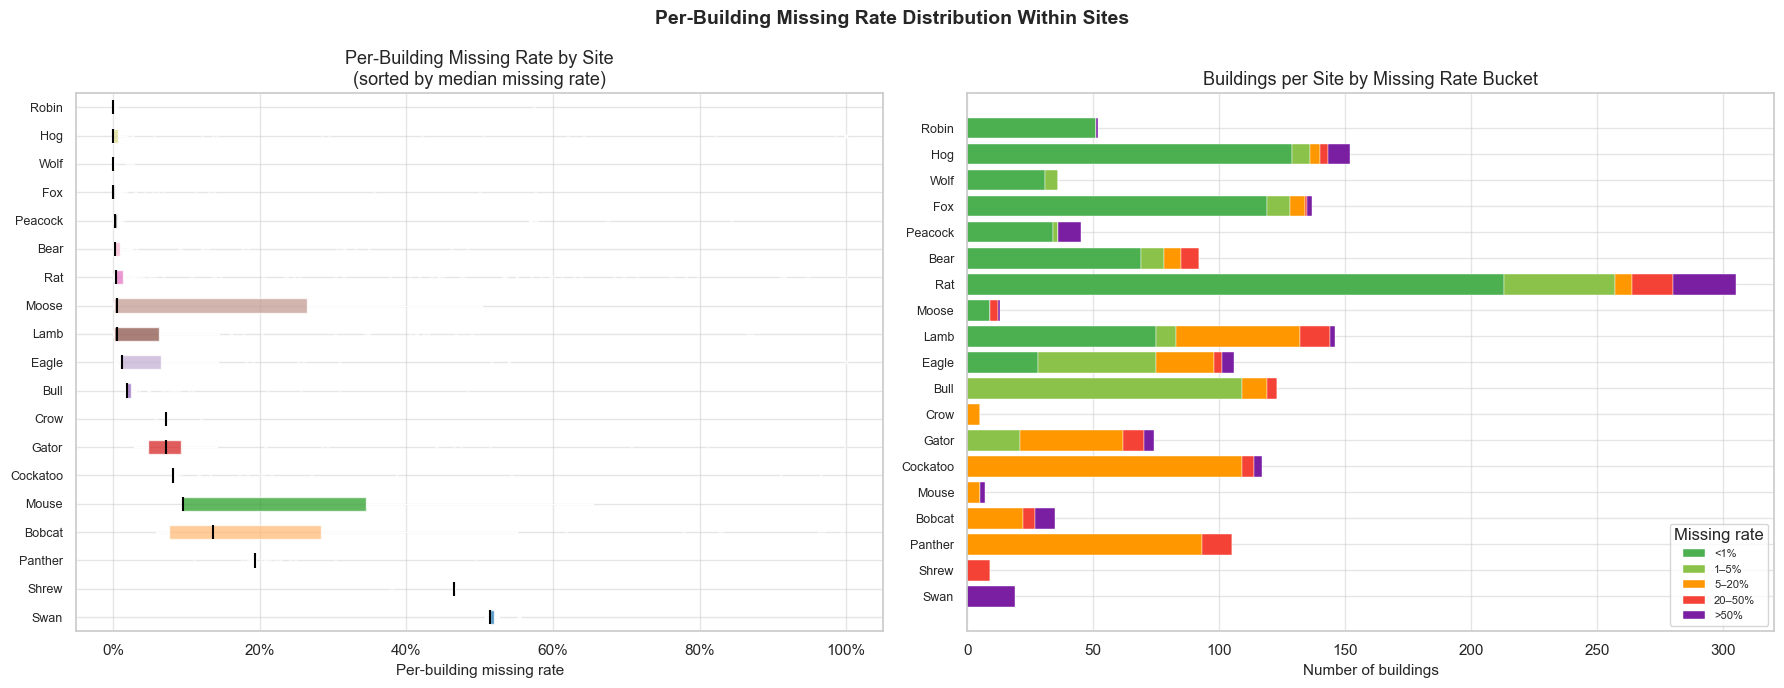

In [17]:
site_order = site_miss_stats.index.tolist()

# Bucket each building's missing rate
bld_miss_df['bucket'] = pd.cut(
    bld_miss_df['missing_rate'],
    bins=[-0.001, 0.01, 0.05, 0.20, 0.50, 1.01],
    labels=['<1%', '1–5%', '5–20%', '20–50%', '>50%']
)
bucket_cols   = ['<1%', '1–5%', '5–20%', '20–50%', '>50%']
bucket_colors = ['#4caf50', '#8bc34a', '#ff9800', '#f44336', '#7b1fa2']
bucket_df = (
    bld_miss_df.groupby(['site_id', 'bucket'], observed=False)
    .size().unstack(fill_value=0)[bucket_cols]
    .loc[site_order]
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: box plot of per-building missing rate by site (sorted by median)
box_data = [
    bld_miss_df.loc[bld_miss_df['site_id'] == s, 'missing_rate'].values
    for s in site_order
]
bp = axes[0].boxplot(
    box_data, vert=False, patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='.', markersize=3, alpha=0.5),
    boxprops=dict(alpha=0.75),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
)
for patch, color in zip(bp['boxes'], plt.cm.tab20.colors):
    patch.set_facecolor(color)
axes[0].set_yticks(range(1, len(site_order) + 1))
axes[0].set_yticklabels(site_order, fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_xlabel('Per-building missing rate')
axes[0].set_title('Per-Building Missing Rate by Site\n(sorted by median missing rate)')

# Right: stacked bar — buildings by missing rate bucket
left = np.zeros(len(site_order))
for label, color in zip(bucket_cols, bucket_colors):
    vals = bucket_df[label].values
    axes[1].barh(range(len(site_order)), vals, left=left,
                 color=color, label=label, edgecolor='white', linewidth=0.3)
    left += vals
axes[1].set_yticks(range(len(site_order)))
axes[1].set_yticklabels(site_order, fontsize=9)
axes[1].set_xlabel('Number of buildings')
axes[1].set_title('Buildings per Site by Missing Rate Bucket')
axes[1].legend(title='Missing rate', loc='lower right', fontsize=8)

plt.suptitle('Per-Building Missing Rate Distribution Within Sites', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Site Variability Profile

In [7]:
var_df = cons_df[['site_id', 'mean', 'std']].copy()
var_df['cv'] = var_df['std'] / var_df['mean']
var_df.sort_values('cv', ascending=False, inplace=True)
var_df.reset_index(drop=True, inplace=True)

display(var_df.style.format({'mean': '{:.3f}', 'std': '{:.3f}', 'cv': '{:.3f}'}))

,site_id,mean,std,cv
0,Gator,72.990,228.251,3.127
1,Lamb,18.110,47.073,2.599
2,Rat,117.027,241.871,2.067
3,Hog,243.002,441.769,1.818
4,Bull,185.884,326.597,1.757
5,Fox,152.834,259.586,1.698
6,Bear,179.596,284.931,1.587
7,Cockatoo,135.386,177.841,1.314
8,Peacock,182.456,234.589,1.286
9,Eagle,196.248,236.405,1.205


## 7. Site Temporal Profiles

In [8]:
def site_profile_by(site, groupby_fn):
    """Return mean consumption for a site grouped by groupby_fn(timestamp)."""
    cols = site_to_blds[site]
    site_mean = elec_idx[cols].mean(axis=1)
    return site_mean.groupby(groupby_fn(site_mean.index)).mean()

hourly_profiles  = {s: site_profile_by(s, lambda idx: idx.hour)        for s in sites}
dow_profiles     = {s: site_profile_by(s, lambda idx: idx.dayofweek)   for s in sites}
monthly_profiles = {s: site_profile_by(s, lambda idx: idx.month)       for s in sites}

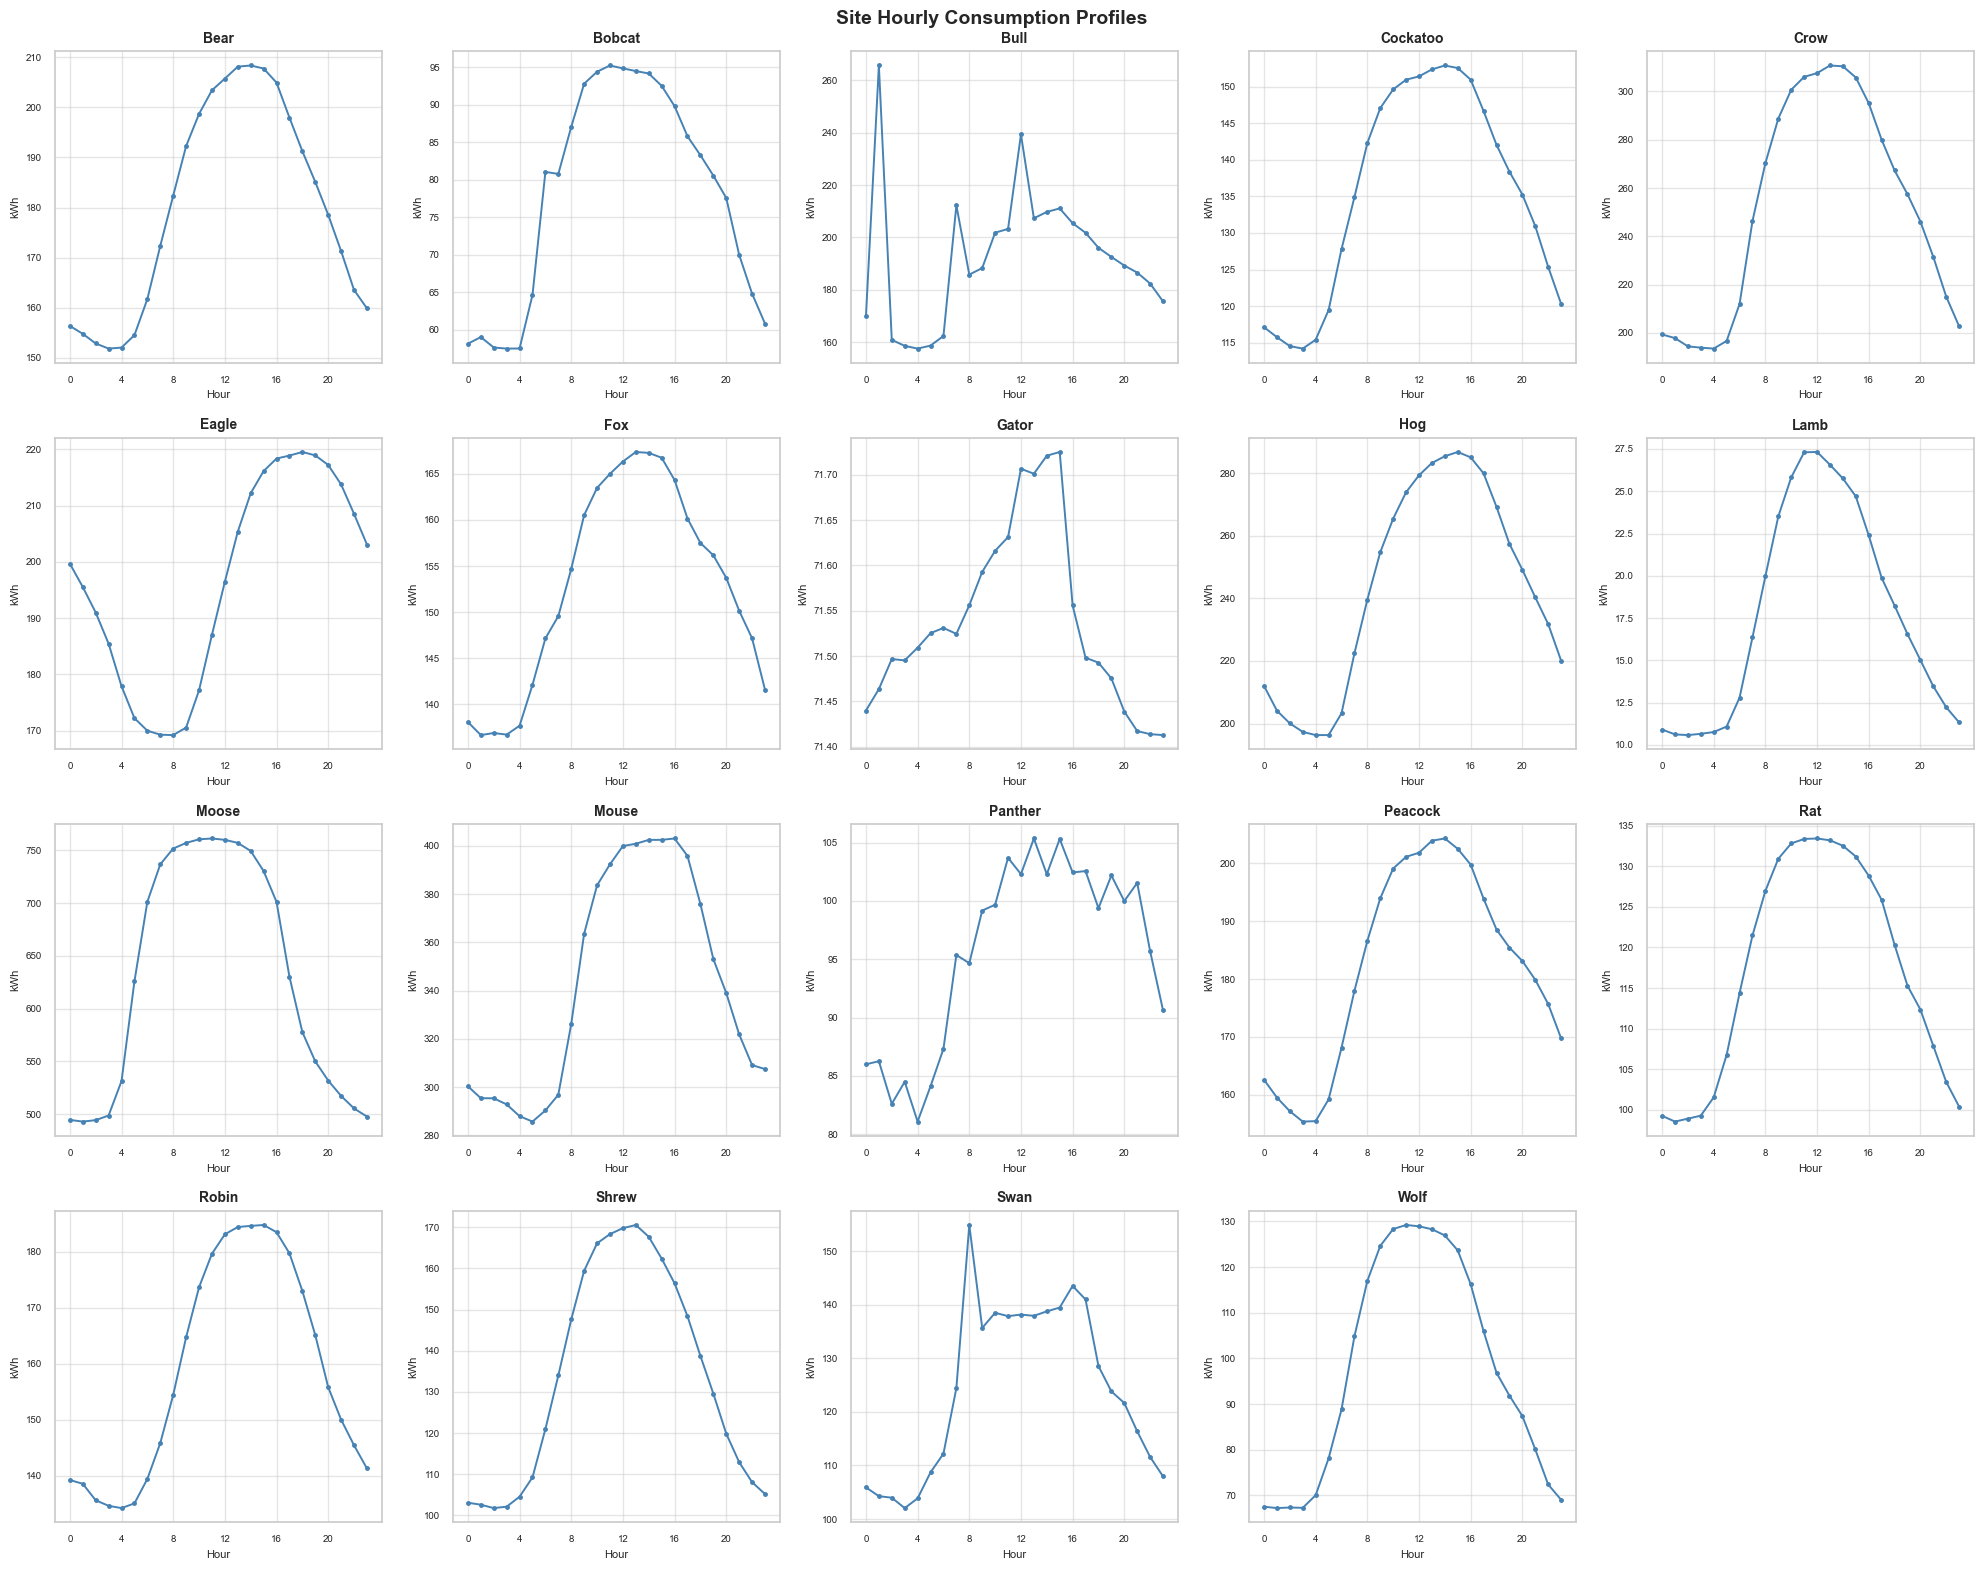

In [9]:
NCOLS, NROWS = 5, 4
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, 16), sharey=False)
axes_flat = axes.flatten()

for i, site in enumerate(sites):
    ax = axes_flat[i]
    profile = hourly_profiles[site]
    ax.plot(profile.index, profile.values, marker='o', markersize=2.5, linewidth=1.4, color='steelblue')
    ax.set_title(site, fontsize=10, fontweight='bold')
    ax.set_xlabel('Hour', fontsize=8)
    ax.set_ylabel('kWh', fontsize=8)
    ax.set_xticks(range(0, 24, 4))
    ax.tick_params(labelsize=7)

for j in range(len(sites), NROWS * NCOLS):
    axes_flat[j].set_visible(False)

fig.suptitle('Site Hourly Consumption Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

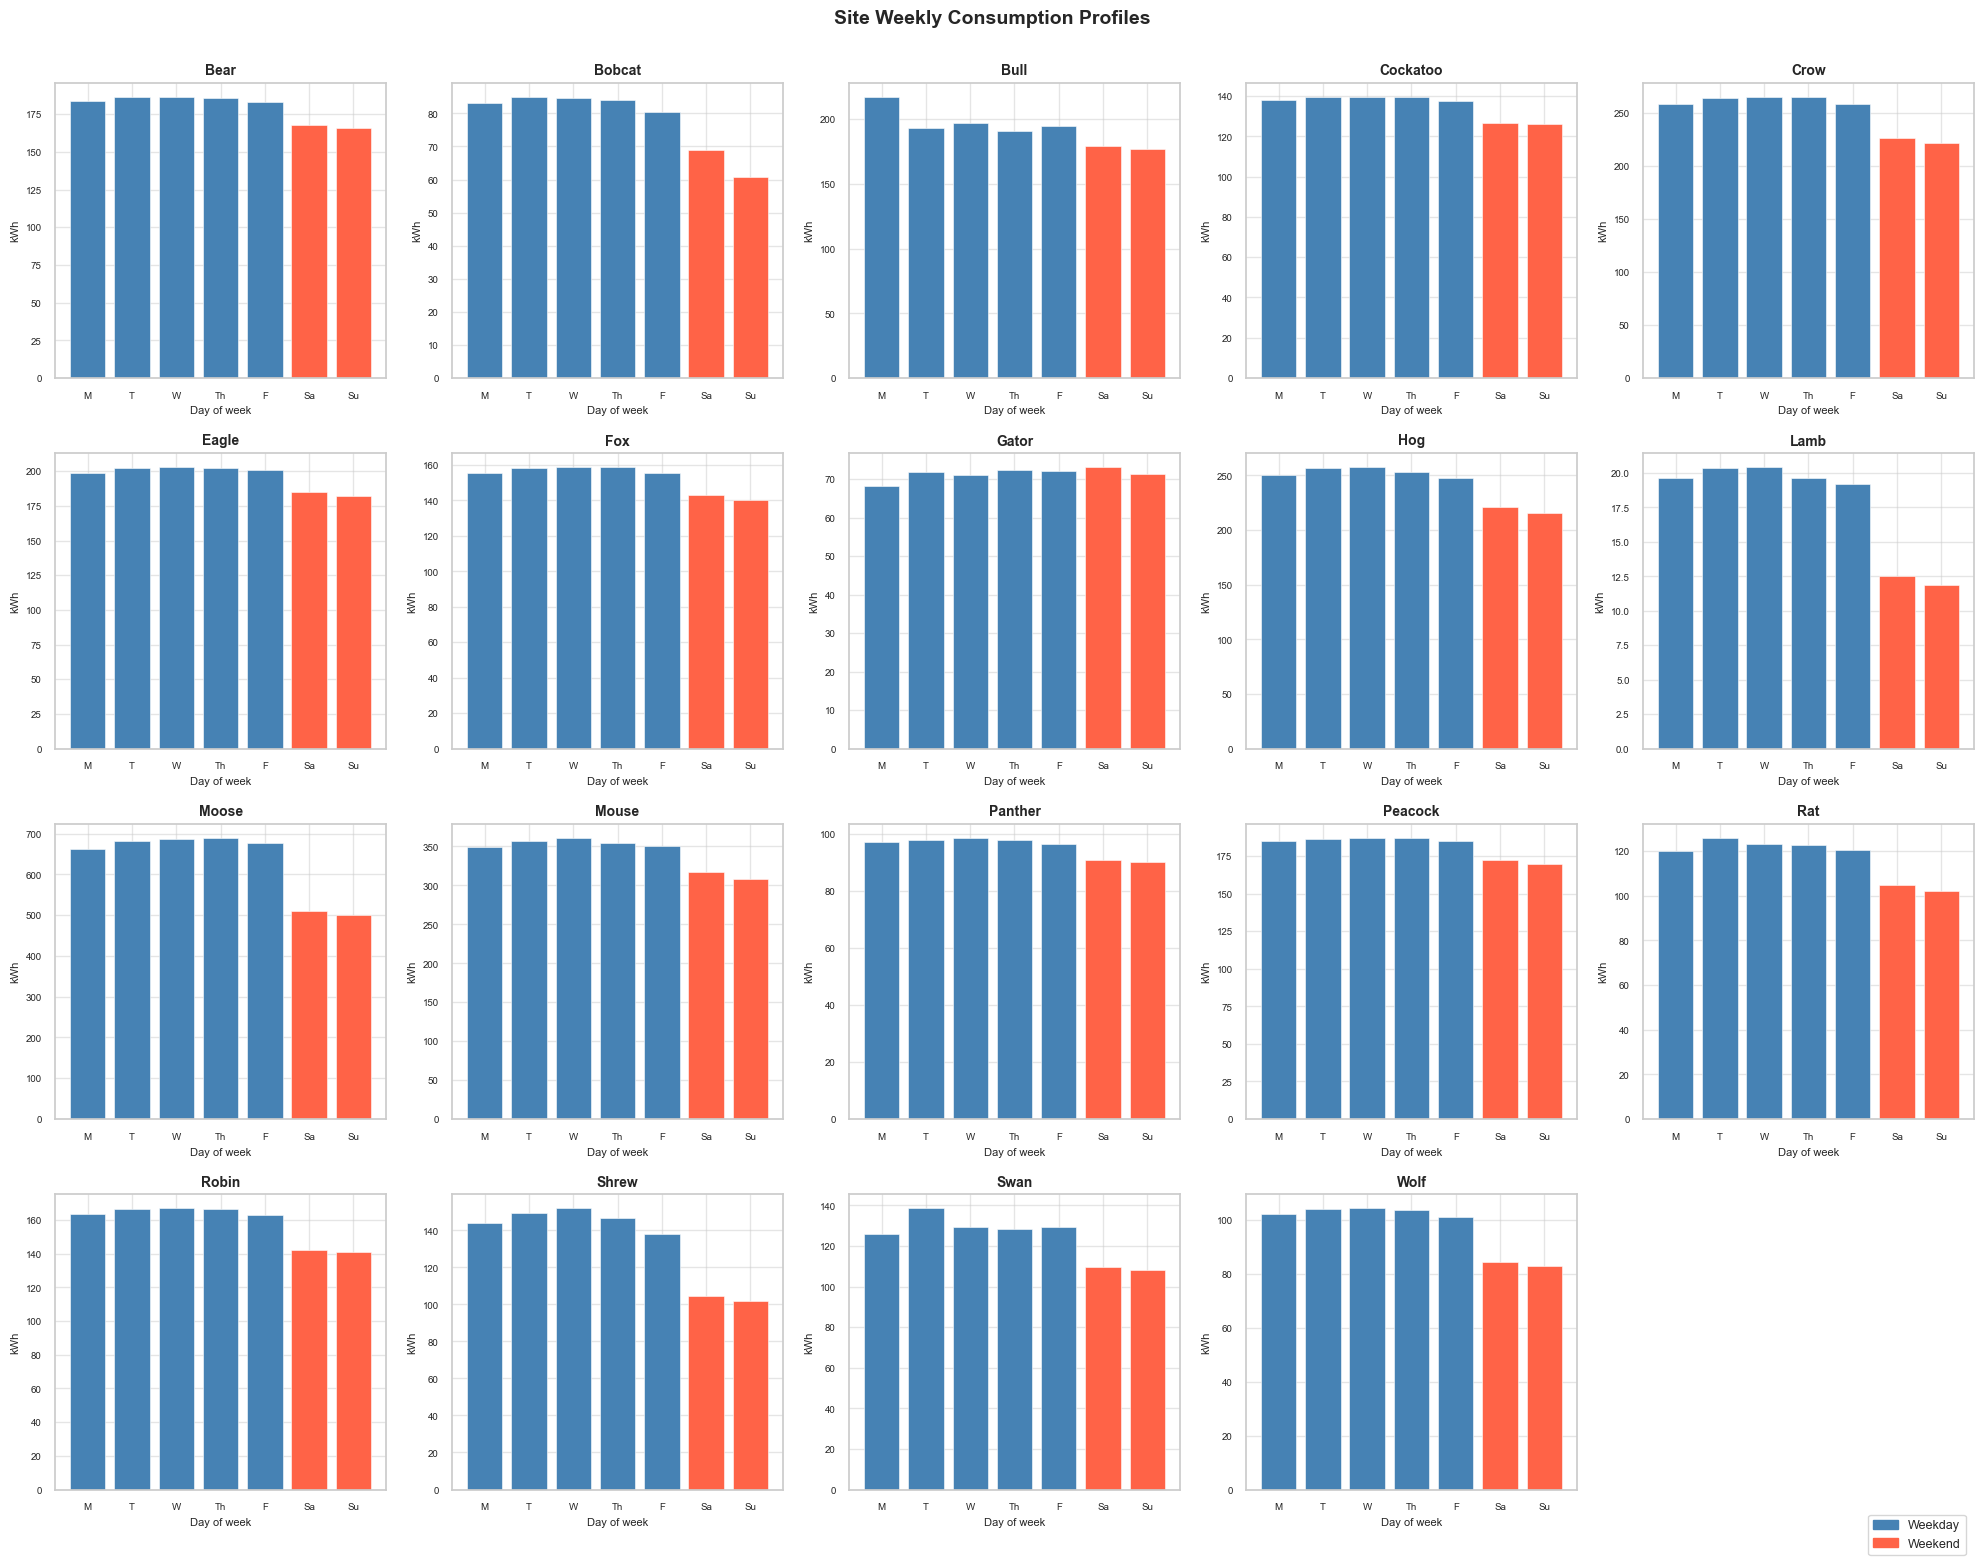

In [10]:
NCOLS, NROWS = 5, 4
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, 16), sharey=False)
axes_flat = axes.flatten()

bar_colors = ['steelblue'] * 5 + ['tomato'] * 2  # Mon-Fri=blue, Sat-Sun=red

for i, site in enumerate(sites):
    ax = axes_flat[i]
    profile = dow_profiles[site].reindex(range(7), fill_value=0)
    ax.bar(range(7), profile.values, color=bar_colors, edgecolor='white', linewidth=0.4)
    ax.set_title(site, fontsize=10, fontweight='bold')
    ax.set_xlabel('Day of week', fontsize=8)
    ax.set_ylabel('kWh', fontsize=8)
    ax.set_xticks(range(7))
    ax.set_xticklabels(['M', 'T', 'W', 'Th', 'F', 'Sa', 'Su'], fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

for j in range(len(sites), NROWS * NCOLS):
    axes_flat[j].set_visible(False)

from matplotlib.patches import Patch
legend_handles = [Patch(color='steelblue', label='Weekday'), Patch(color='tomato', label='Weekend')]
fig.legend(handles=legend_handles, loc='lower right', bbox_to_anchor=(0.99, 0.01), fontsize=9)

fig.suptitle('Site Weekly Consumption Profiles', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

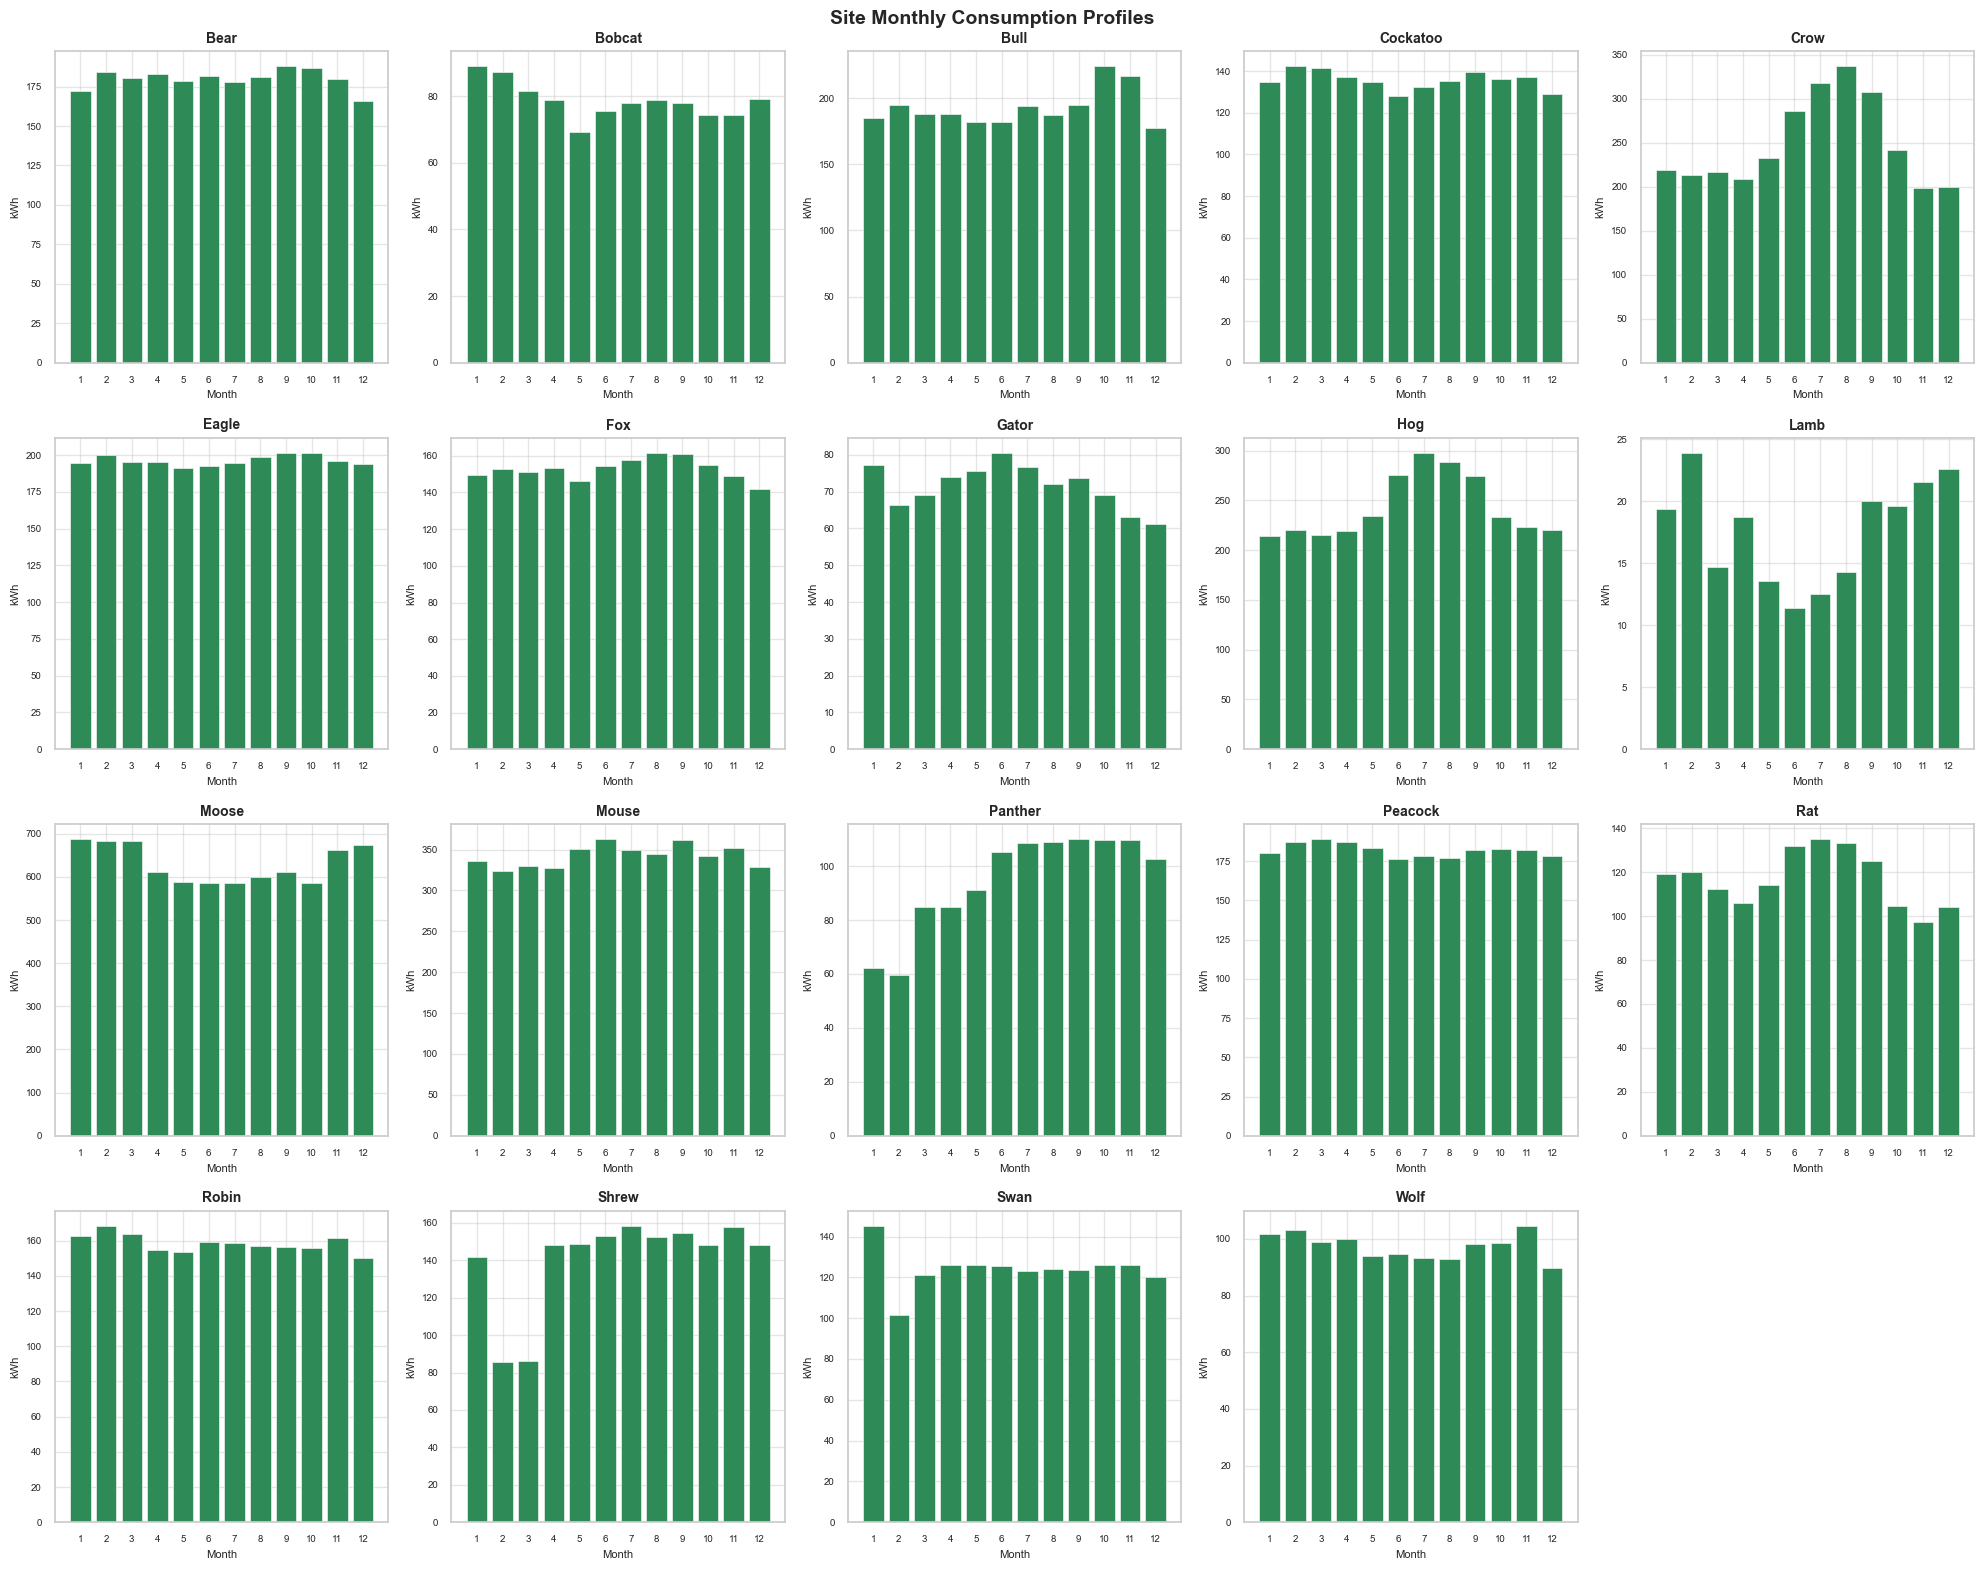

In [11]:
NCOLS, NROWS = 5, 4
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, 16), sharey=False)
axes_flat = axes.flatten()

for i, site in enumerate(sites):
    ax = axes_flat[i]
    profile = monthly_profiles[site].reindex(range(1, 13), fill_value=0)
    ax.bar(range(1, 13), profile.values, color='seagreen', edgecolor='white', linewidth=0.4)
    ax.set_title(site, fontsize=10, fontweight='bold')
    ax.set_xlabel('Month', fontsize=8)
    ax.set_ylabel('kWh', fontsize=8)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(range(1, 13), fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

for j in range(len(sites), NROWS * NCOLS):
    axes_flat[j].set_visible(False)

fig.suptitle('Site Monthly Consumption Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

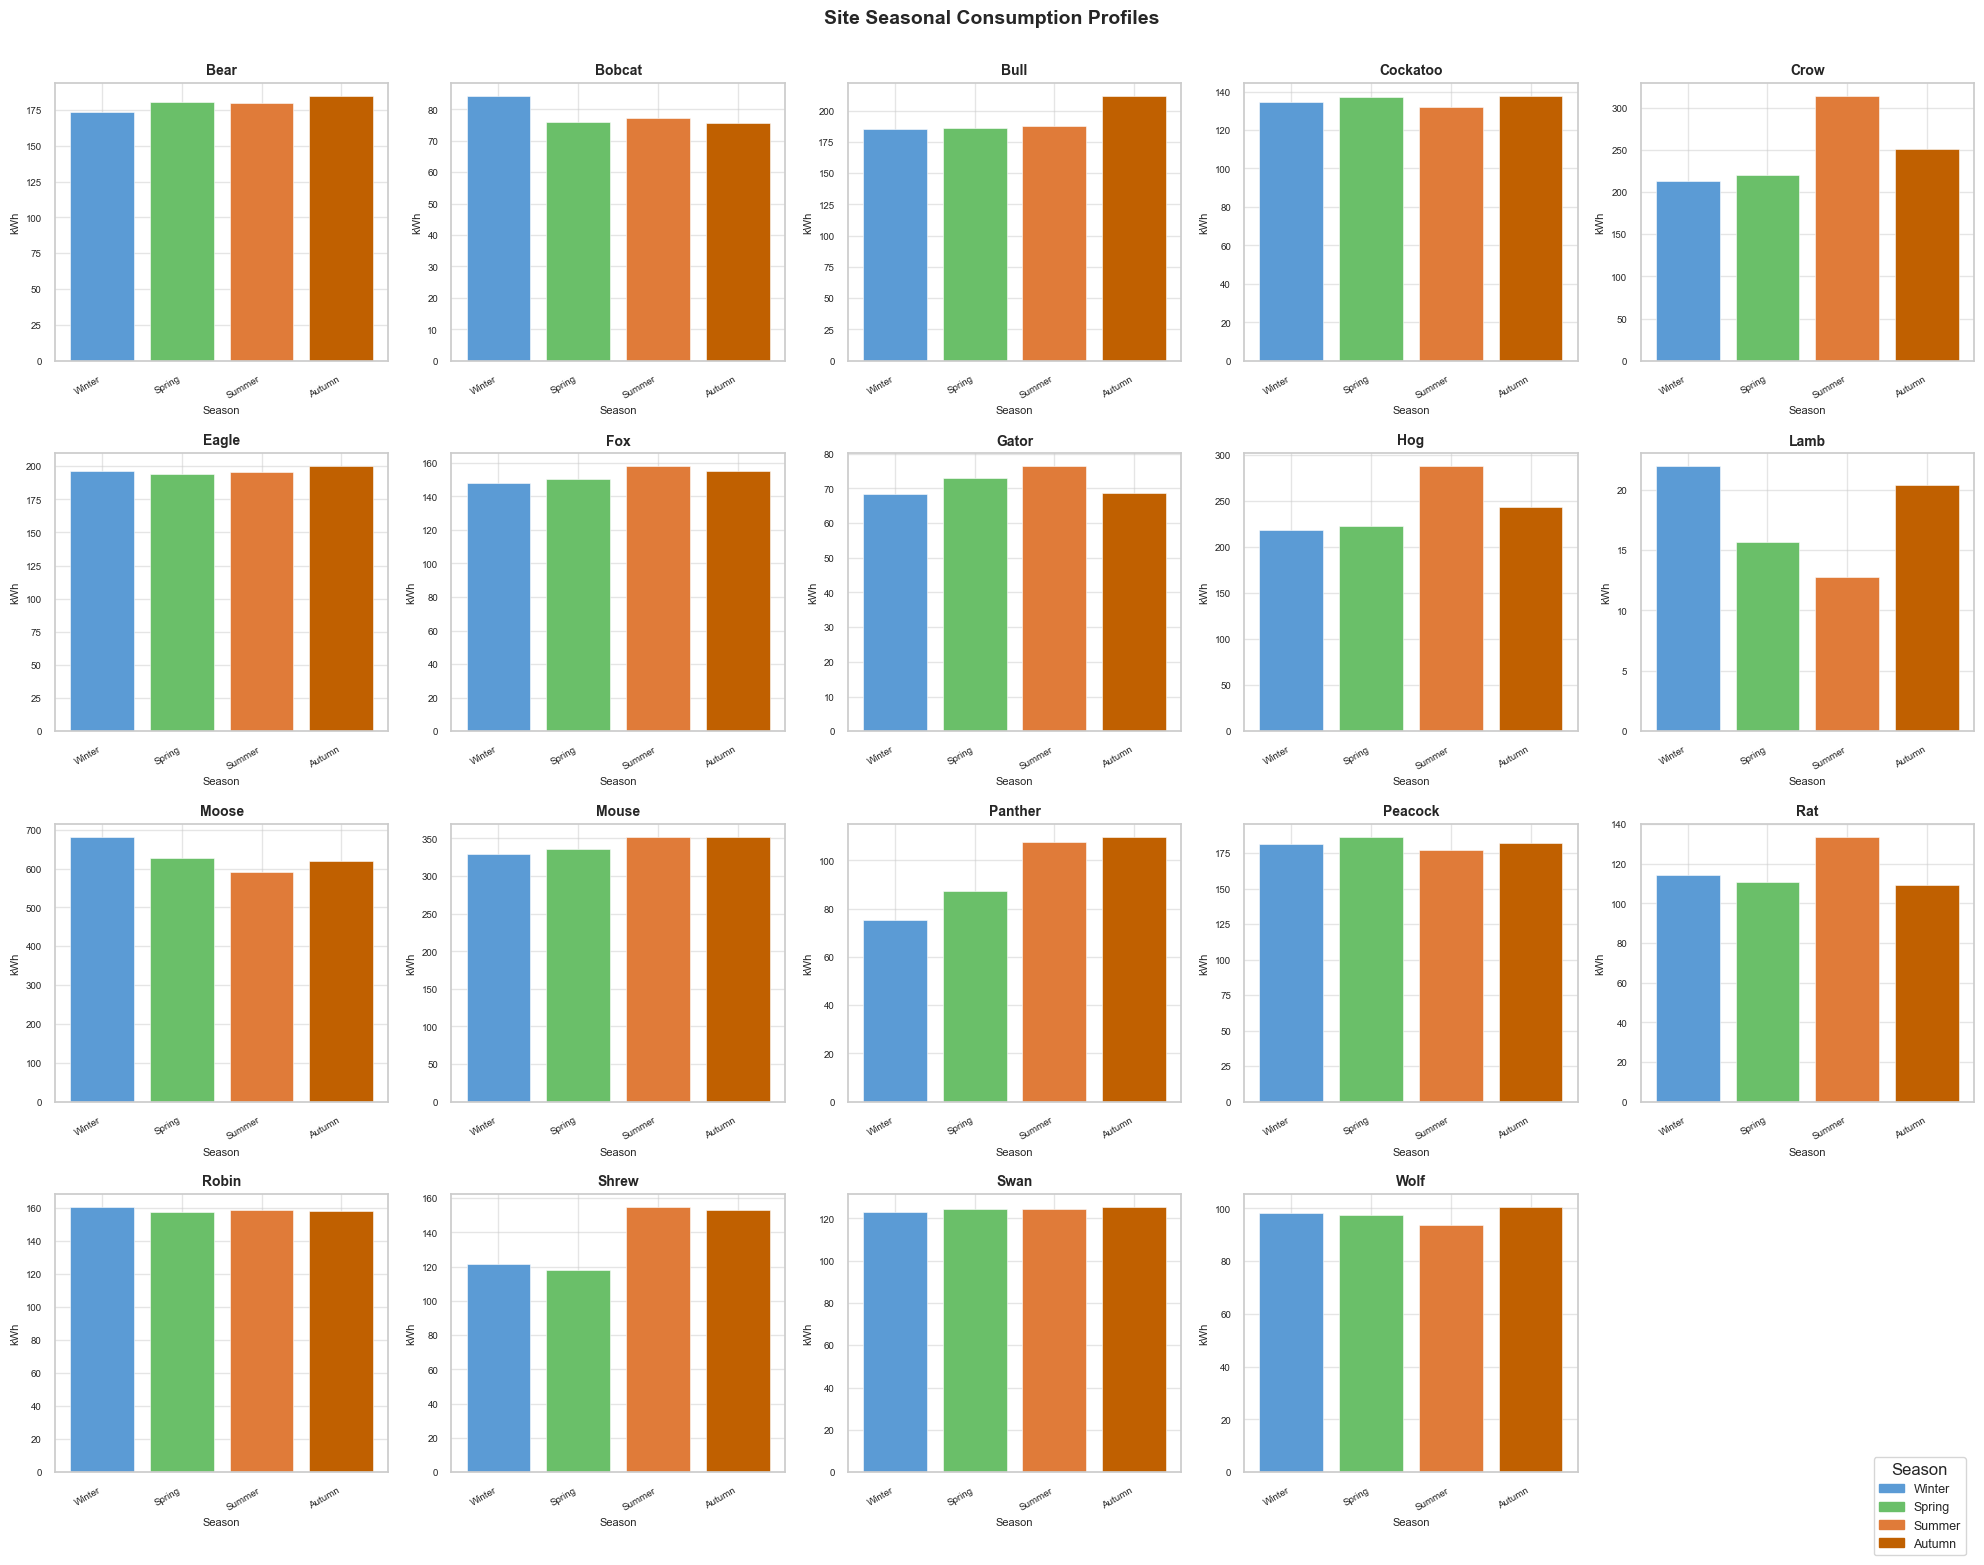

In [12]:
from matplotlib.patches import Patch

SEASON_MAP = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring',  4: 'Spring', 5: 'Spring',
    6: 'Summer',  7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}
SEASON_ORDER  = ['Winter', 'Spring', 'Summer', 'Autumn']
SEASON_COLORS = {'Winter': '#5b9bd5', 'Spring': '#6abf69',
                 'Summer': '#e07b39', 'Autumn': '#c06000'}

def site_seasonal_profile(site):
    cols = site_to_blds[site]
    site_mean = elec_idx[cols].mean(axis=1)
    season_series = site_mean.index.month.map(SEASON_MAP)
    return site_mean.groupby(season_series).mean().reindex(SEASON_ORDER)

seasonal_profiles = {s: site_seasonal_profile(s) for s in sites}

NCOLS, NROWS = 5, 4
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, 16), sharey=False)
axes_flat = axes.flatten()

for i, site in enumerate(sites):
    ax = axes_flat[i]
    profile = seasonal_profiles[site]
    colors = [SEASON_COLORS[s] for s in SEASON_ORDER]
    ax.bar(SEASON_ORDER, profile.values, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_title(site, fontsize=10, fontweight='bold')
    ax.set_xlabel('Season', fontsize=8)
    ax.set_ylabel('kWh', fontsize=8)
    ax.set_xticklabels(SEASON_ORDER, fontsize=7, rotation=30, ha='right')
    ax.tick_params(axis='y', labelsize=7)

for j in range(len(sites), NROWS * NCOLS):
    axes_flat[j].set_visible(False)

legend_handles = [Patch(color=SEASON_COLORS[s], label=s) for s in SEASON_ORDER]
fig.legend(handles=legend_handles, loc='lower right', bbox_to_anchor=(0.99, 0.01),
           fontsize=9, title='Season')

fig.suptitle('Site Seasonal Consumption Profiles', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

## 8. Site Metadata Profile

In [13]:
meta_matched = meta[meta['building_id'].isin(matched)].copy()

site_meta = meta_matched.groupby('site_id').agg(
    avg_sqm        = ('sqm', 'mean'),
    median_sqm     = ('sqm', 'median'),
    total_sqm      = ('sqm', 'sum'),
    avg_yearbuilt  = ('yearbuilt', 'mean'),
    top_usage      = ('primaryspaceusage', lambda x: x.mode().iloc[0] if len(x.mode()) else np.nan),
).reset_index()

display(site_meta.style.format({'avg_sqm': '{:.0f}', 'median_sqm': '{:.0f}',
                                 'total_sqm': '{:,.0f}', 'avg_yearbuilt': '{:.1f}'}))

,site_id,avg_sqm,median_sqm,total_sqm,avg_yearbuilt,top_usage
0,Bear,8778,6357,"807,571",1954.2,Education
1,Bobcat,7032,6052,"246,104",nan,Education
2,Bull,13440,9435,"1,653,097",nan,Education
3,Cockatoo,7828,6132,"915,878",1962.3,Education
4,Crow,9714,8659,"48,571",nan,Education
5,Eagle,8727,6453,"925,109",nan,Office
6,Fox,9307,6635,"1,275,032",1975.2,Education
7,Gator,3017,743,"223,261",nan,Public services
8,Hog,12229,8520,"1,858,754",nan,Office
9,Lamb,3487,2173,"509,109",1960.9,Education


## 9. Site Building Type Mix

In [14]:
type_mix = meta_matched.groupby(['site_id', 'primaryspaceusage']).size().unstack(fill_value=0)
type_mix.index.name = 'site_id'

print('Building count by site and usage type:')
display(type_mix)

type_mix_pct = type_mix.div(type_mix.sum(axis=1), axis=0) * 100
print('\nNormalized percentage by site:')
display(type_mix_pct.style.format('{:.1f}%'))

Building count by site and usage type:


primaryspaceusage,Education,Entertainment/public assembly,Food sales and service,Healthcare,Lodging/residential,Manufacturing/industrial,Office,Other,Parking,Public services,Religious worship,Retail,Services,Technology/science,Utility,Warehouse/storage
site_id,,,,,,,,,,,,,,,,
Bear,67,9,0,0,4,0,0,0,3,6,0,0,0,2,1,0
Bobcat,17,4,0,0,3,0,5,3,0,1,0,0,0,1,0,1
Bull,63,17,0,0,19,0,17,0,0,2,0,0,5,0,0,0
Cockatoo,43,16,0,0,28,2,18,0,0,6,1,0,0,1,2,0
Crow,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Eagle,26,11,2,10,10,0,40,0,0,7,0,0,0,0,0,0
Fox,63,21,2,1,12,0,24,0,3,6,1,1,0,0,1,2
Gator,0,26,0,0,0,0,8,9,0,29,0,0,0,0,0,2
Hog,24,11,1,3,11,5,73,3,8,5,0,0,4,1,0,3



Normalized percentage by site:


primaryspaceusage,Education,Entertainment/public assembly,Food sales and service,Healthcare,Lodging/residential,Manufacturing/industrial,Office,Other,Parking,Public services,Religious worship,Retail,Services,Technology/science,Utility,Warehouse/storage
site_id,,,,,,,,,,,,,,,,
Bear,72.8%,9.8%,0.0%,0.0%,4.3%,0.0%,0.0%,0.0%,3.3%,6.5%,0.0%,0.0%,0.0%,2.2%,1.1%,0.0%
Bobcat,48.6%,11.4%,0.0%,0.0%,8.6%,0.0%,14.3%,8.6%,0.0%,2.9%,0.0%,0.0%,0.0%,2.9%,0.0%,2.9%
Bull,51.2%,13.8%,0.0%,0.0%,15.4%,0.0%,13.8%,0.0%,0.0%,1.6%,0.0%,0.0%,4.1%,0.0%,0.0%,0.0%
Cockatoo,36.8%,13.7%,0.0%,0.0%,23.9%,1.7%,15.4%,0.0%,0.0%,5.1%,0.9%,0.0%,0.0%,0.9%,1.7%,0.0%
Crow,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Eagle,24.5%,10.4%,1.9%,9.4%,9.4%,0.0%,37.7%,0.0%,0.0%,6.6%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
Fox,46.0%,15.3%,1.5%,0.7%,8.8%,0.0%,17.5%,0.0%,2.2%,4.4%,0.7%,0.7%,0.0%,0.0%,0.7%,1.5%
Gator,0.0%,35.1%,0.0%,0.0%,0.0%,0.0%,10.8%,12.2%,0.0%,39.2%,0.0%,0.0%,0.0%,0.0%,0.0%,2.7%
Hog,15.8%,7.2%,0.7%,2.0%,7.2%,3.3%,48.0%,2.0%,5.3%,3.3%,0.0%,0.0%,2.6%,0.7%,0.0%,2.0%


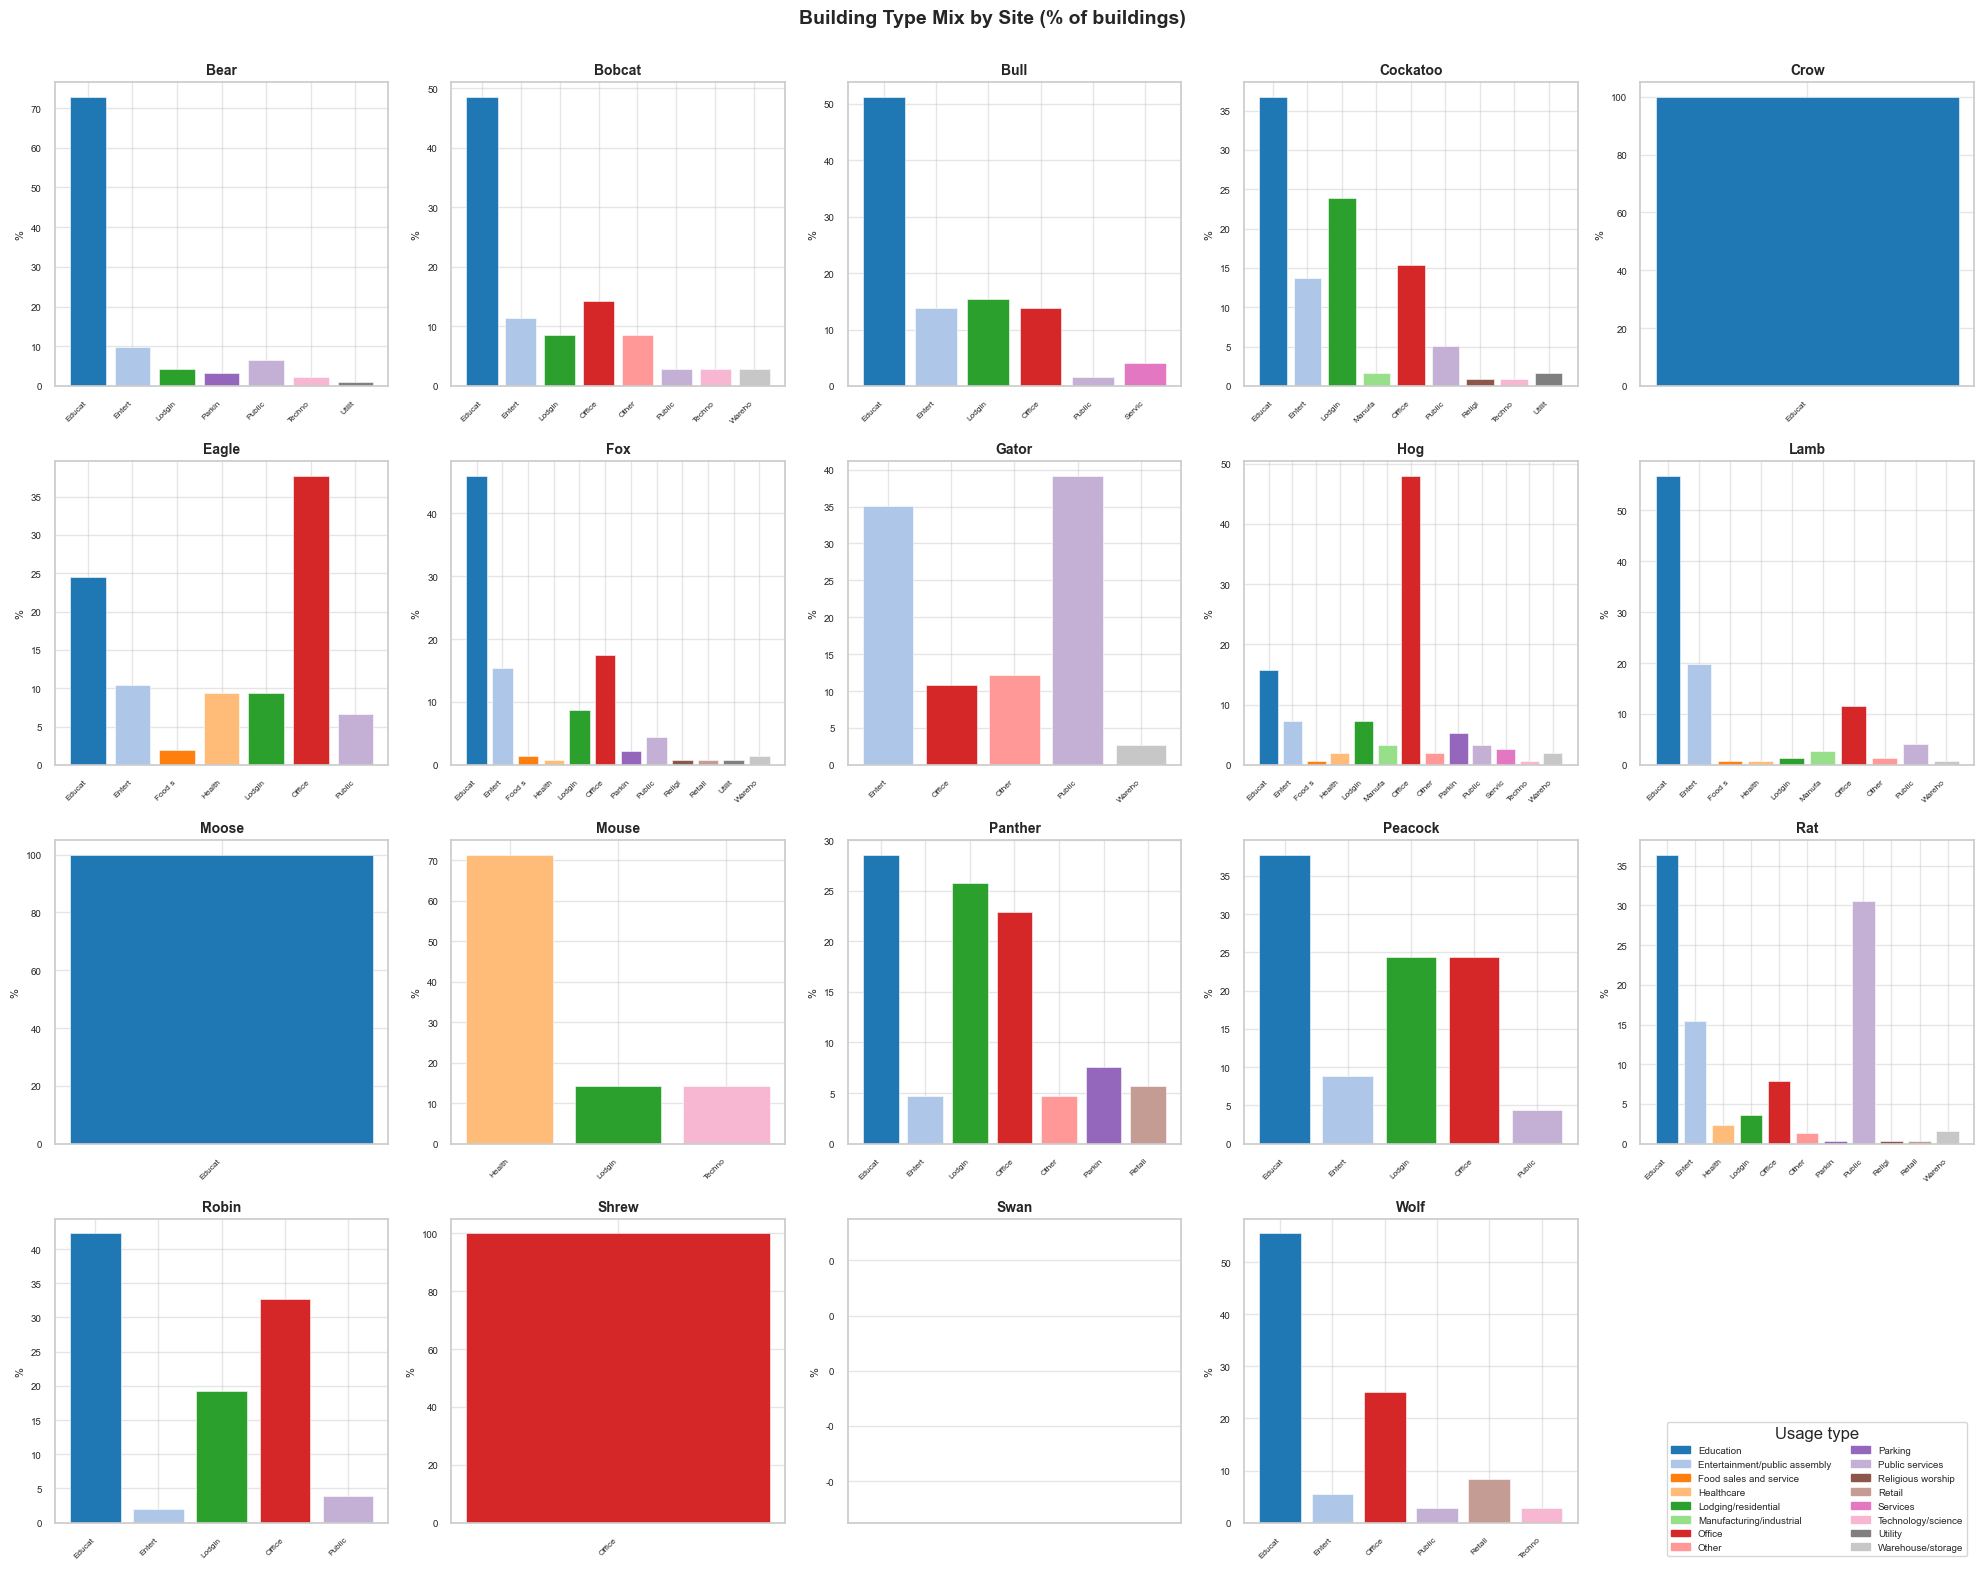

In [15]:
colors = plt.cm.tab20.colors
usage_types = list(type_mix_pct.columns)

NCOLS, NROWS = 5, 4
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(20, 16))
axes_flat = axes.flatten()

for i, site in enumerate(sites):
    ax = axes_flat[i]
    row = type_mix_pct.loc[site] if site in type_mix_pct.index else pd.Series(dtype=float)
    row = row[row > 0]
    ax.bar(range(len(row)), row.values,
           color=[colors[usage_types.index(u) % len(colors)] for u in row.index],
           edgecolor='white', linewidth=0.4)
    ax.set_title(site, fontsize=10, fontweight='bold')
    ax.set_ylabel('%', fontsize=8)
    ax.set_xticks(range(len(row)))
    ax.set_xticklabels(
        [u[:6] for u in row.index],
        rotation=45, ha='right', fontsize=6
    )
    ax.tick_params(axis='y', labelsize=7)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

for j in range(len(sites), NROWS * NCOLS):
    axes_flat[j].set_visible(False)

# Shared legend
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors[k % len(colors)], label=u)
    for k, u in enumerate(usage_types)
]
fig.legend(handles=legend_patches, title='Usage type', fontsize=7,
           loc='lower right', bbox_to_anchor=(0.99, 0.01), ncol=2)

fig.suptitle('Building Type Mix by Site (% of buildings)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.0, 1, 0.98])
plt.show()

## Summary Observations

- **Site portfolio sizes are uneven**: Rat is the largest site with 305 buildings, followed by Hog (163), Lamb (147), Fox (137), and Panther (136). Site-level aggregates are therefore strongly influenced by a few large campuses.
- **Consumption concentration differs from building count**: Hog has the highest total consumption, about 608M kWh, and a high mean reading near 243 kWh. Rat is also large by total consumption, while Bull stands out because of extreme high readings.
- **Missing data is site-specific**: Swan (52.3%), Shrew (45.6%), Bobcat (28.4%), Mouse (24.6%), and Panther (19.8%) have the worst site-average missing rates. These sites should receive stricter quality checks and imputation review before downstream scoring.
- **High site-average missing rates are driven by concentrated bad buildings, not uniform degradation**: The per-building distribution (Section 5) shows that most sites have a large majority of buildings with <1% missing, while the high averages for Swan, Shrew, Bobcat, and Mouse are pulled up by a small number of severely missing buildings. This means targeted per-building exclusion is more appropriate than blanket site-level treatment.
- **Variability is too high for simple site-wide thresholds**: Gator, Lamb, Rat, Hog, and Bull have the highest coefficients of variation. Per-building or usage-aware normalization will be more reliable than a single site-level threshold.
- **Site type mix explains some profile differences**: Gator is dominated by Public services and Other, Shrew is Office-only, Mouse is Healthcare-heavy, and Rat is a large mixed campus. This makes primary usage an important segmentation variable for anomaly rules.
- **Swan needs special handling**: all Swan electricity buildings carry `unknown` primary usage labels, so Swan contributes to site-level EDA but is excluded from primary-usage analysis.